# 3D Real-World Example: Jacketed Non-Isothermal CSTR — Koopman-Eigenfunction Lyapunov Function

**Real-world application.** This extends the 2D CSTR example to a genuinely **3D** chemical-process
model: a non-isothermal CSTR (Arrhenius/exponential kinetics) whose reactor temperature is
regulated through a **cooling jacket** with its own thermal dynamics. Adding the jacket
temperature as a third state is exactly how real reactor models are built in process control
(the reactor cannot reject heat instantaneously — the jacket has its own thermal mass and
coolant exchange). The model is

$$
\dot x_1 = -x_1 + D_a(1-x_1)e^{x_2}
$$
$$
\dot x_2 = -(1+\beta)x_2 + B\,D_a(1-x_1)e^{x_2} + \beta_c(x_3-x_2)
$$
$$
\dot x_3 = \beta_j(x_2-x_3) - \beta_j\gamma\,x_3
$$

where $x_1$ = dimensionless conversion, $x_2$ = dimensionless reactor temperature, $x_3$ =
dimensionless jacket temperature. $\beta_c$ is the reactor$\to$jacket heat-transfer coefficient,
$\beta_j$ is the jacket thermal-response rate, and $\gamma$ is the jacket-to-coolant heat-loss
coefficient. The nonlinearity is still the Arrhenius exponential $e^{x_2}$, but it now lives in a
genuinely 3-dimensional state space with a non-diagonal, non-trivially-coupled linearization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## 1. Steady states and choice of operating point

As in the 2D CSTR example, this model has multiple steady states. We locate them with a
multi-start Newton search and linearize at each to find one with **three real, negative,
distinct, non-resonant** eigenvalues — the regime this method applies to.

In [2]:
B, Da, beta, bc, bj, gamma = 8.0, 0.085, 0.5, 0.2, 0.8, 0.5

def f(X):
    X = np.atleast_2d(X)
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    v1 = -x1 + Da*(1-x1)*np.exp(x2)
    v2 = -(1+beta)*x2 + B*Da*(1-x1)*np.exp(x2) + bc*(x3-x2)
    v3 = bj*(x2-x3) - bj*gamma*x3
    return np.stack([v1, v2, v3], axis=1)

def jac_fd(x, h=1e-6):
    J = np.zeros((3, 3))
    for k in range(3):
        e = np.zeros(3); e[k] = h
        J[:, k] = (f(np.array([x+e]))[0] - f(np.array([x-e]))[0]) / (2*h)
    return J

def newton(x0, iters=300, tol=1e-13, cap=2.0):
    x = np.array(x0, dtype=float)
    for _ in range(iters):
        Fx = f(np.array([x]))[0]
        if np.linalg.norm(Fx) < tol:
            return x, True
        J = jac_fd(x)
        try:
            dx = np.linalg.solve(J, -Fx)
        except np.linalg.LinAlgError:
            return x, False
        if np.linalg.norm(dx) > cap:
            dx = dx/np.linalg.norm(dx)*cap
        x = x + dx
        if np.any(np.abs(x) > 1e4):
            return x, False
    return x, np.linalg.norm(f(np.array([x]))[0]) < 1e-10

found = []
rng0 = np.random.default_rng(1)
for _ in range(3000):
    x0 = rng0.uniform(-1, 8, size=3)
    sol, ok = newton(x0)
    if ok and not any(np.linalg.norm(sol-s) < 1e-4 for s in found):
        found.append(sol)
found = sorted(found, key=lambda s: s[1])

print(f"Steady states found ({len(found)}):")
for s in found:
    ev = np.linalg.eigvals(jac_fd(s))
    print(f"  x*={np.round(s,4)}   eigenvalues={np.round(ev,4)}")

Steady states found (3):
  x*=[0.1645 0.84   0.56  ]   eigenvalues=[-0.5348 -1.0414 -1.2047]
  x*=[0.4176 2.1327 1.4218]   eigenvalues=[ 0.7531+0.j     -1.0145+0.0893j -1.0145-0.0893j]
  x*=[0.8878 4.5333 3.0222]   eigenvalues=[-1.8681+2.2302j -1.8681-2.2302j -0.9724+0.j    ]


Exactly one steady state — the low-conversion (cold) operating point — has three real,
negative, distinct eigenvalues. The other two are unstable / oscillatory (complex eigenvalues
with positive or near-zero real parts) and are excluded, as in the 2D CSTR example.

In [3]:
xs = found[0].copy()
for _ in range(50):
    Fx = f(np.array([xs]))[0]
    J = jac_fd(xs)
    xs = xs - np.linalg.solve(J, Fx)
print("refined equilibrium x* =", xs, "  f(x*) =", f(np.array([xs]))[0])

E = jac_fd(xs)
print("\nJacobian E at x*:\n", E)
eigvals, R = np.linalg.eig(E)
eigvals_check, VL = np.linalg.eig(E.T)
lams = eigvals.real
ws = [VL[:, i].real for i in range(3)]
print("\nEigenvalues:", lams, " (real, negative, distinct)")
for i in range(3):
    for j in range(3):
        if i != j:
            print(f"  lambda_{i}/lambda_{j} = {lams[i]/lams[j]:.4f}")

other_dists = [np.linalg.norm(xs - s) for s in found[1:]]
print("\ndistances from x* to other equilibria:", other_dists)
print("(collocation domain below uses a radius safely inside the smallest of these)")

def g(Y):
    Y = np.atleast_2d(Y)
    return f(Y + xs)

def G(Y):
    Y = np.atleast_2d(Y)
    return g(Y) - Y @ E.T

print("\nG(0) (should be ~0):", G(np.zeros((1, 3)))[0])

refined equilibrium x* = [0.1645 0.84   0.56  ]   f(x*) = [0. 0. 0.]

Jacobian E at x*:
 [[-1.1969  0.1645  0.    ]
 [-1.5752 -0.3839  0.2   ]
 [ 0.      0.8    -1.2   ]]

Eigenvalues: [-0.5348 -1.0414 -1.2047]  (real, negative, distinct)
  lambda_0/lambda_1 = 0.5135
  lambda_0/lambda_2 = 0.4439
  lambda_1/lambda_0 = 1.9472
  lambda_1/lambda_2 = 0.8644
  lambda_2/lambda_0 = 2.2527
  lambda_2/lambda_1 = 1.1569

distances from x* to other equilibria: [np.float64(1.5740238630674375), np.float64(4.497315624666902)]
(collocation domain below uses a radius safely inside the smallest of these)

G(0) (should be ~0): [0. 0. 0.]


## 2. Koopman eigenfunction decomposition via kernel PDE collocation

Same generalized 3D kernel machinery used throughout this notebook series, with genuine left
eigenvectors $w_i$ of the non-diagonal $3\times3$ Jacobian $E$, working in shifted coordinates
$y=x-x^*$.

In [4]:
def make_kernel_funcs(sigmas):
    sigmas = np.asarray(sigmas, dtype=float)
    d = len(sigmas)

    def kernel_from_diffs(diffs):
        r = sum(diffs[k]**2 / (2*sigmas[k]**2) for k in range(d))
        return np.exp(-r)

    def dx(diffs, K, k):
        return -diffs[k] / sigmas[k]**2 * K

    def dy(diffs, K, k):
        return diffs[k] / sigmas[k]**2 * K

    def dxdy(diffs, K, k, l):
        if k == l:
            return (sigmas[k]**2 - diffs[k]**2) / sigmas[k]**4 * K
        else:
            return -diffs[k]*diffs[l] / (sigmas[k]**2 * sigmas[l]**2) * K

    return kernel_from_diffs, dx, dy, dxdy


def pairwise_diffs(X, Y):
    d = X.shape[1]
    return [X[:, k][:, None] - Y[:, k][None, :] for k in range(d)]


def build_gram_matrix_d(ev, XY, F_val, sigmas):
    n, d = XY.shape
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs = pairwise_diffs(XY, XY)
    K_Matrix = kernel_from_diffs(diffs)
    Dx = [dx(diffs, K_Matrix, k) for k in range(d)]
    D2 = {}
    for k in range(d):
        for l in range(k, d):
            D2[(k, l)] = dxdy(diffs, K_Matrix, k, l)
            D2[(l, k)] = D2[(k, l)]

    zero = np.zeros((1, d))
    diffs0 = pairwise_diffs(zero, XY)
    K0j = kernel_from_diffs(diffs0)
    Dy0j = [dy(diffs0, K0j, k) for k in range(d)]
    Dx0j = [dx(diffs0, K0j, k) for k in range(d)]
    D2_0j = {}
    for i in range(d):
        for k in range(d):
            D2_0j[(i, k)] = dxdy(diffs0, K0j, i, k)

    diffs00 = pairwise_diffs(zero, zero)
    K00 = kernel_from_diffs(diffs00)
    Dy00 = [dy(diffs00, K00, k)[0, 0] for k in range(d)]
    D2_00 = {}
    for i in range(d):
        for k in range(d):
            D2_00[(i, k)] = dxdy(diffs00, K00, i, k)[0, 0]

    K = np.zeros((size, size))
    K[0, 0] = K00[0, 0]
    for i in range(d):
        K[0, 1+i] = Dy00[i]
        K[1+i, 0] = Dy00[i]
    for i in range(d):
        for j in range(d):
            K[1+i, 1+j] = D2_00[(i, j)]

    F1j_list = [F_val[:, k] for k in range(d)]

    k0_pde = np.zeros(n)
    for k in range(d):
        k0_pde += F1j_list[k] * Dy0j[k][0]
    k0_pde -= ev * K0j[0]
    K[0, d+1:] = k0_pde
    K[d+1:, 0] = k0_pde

    for i in range(d):
        ki_pde = np.zeros(n)
        for k in range(d):
            ki_pde += F1j_list[k] * D2_0j[(i, k)][0]
        ki_pde -= ev * Dx0j[i][0]
        K[1+i, d+1:] = ki_pde
        K[d+1:, 1+i] = ki_pde

    Fi = [F1j_list[k][:, None] for k in range(d)]
    Fj = [F1j_list[k][None, :] for k in range(d)]

    k33 = np.zeros((n, n))
    for k in range(d):
        for l in range(d):
            k33 += Fi[k] * Fj[l] * D2[(k, l)]
    cross = np.zeros((n, n))
    for k in range(d):
        cross += Fi[k] * Dx[k] + Fj[k] * (-Dx[k])
    k33 -= ev * cross
    k33 += ev**2 * K_Matrix

    K[d+1:, d+1:] = k33
    return K


def representer_vector_d(X_train, X_test, ev, sigmas, F_train):
    n, d = X_train.shape
    m = X_test.shape[0]
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs_tt = pairwise_diffs(X_test, X_train)
    K_tt = kernel_from_diffs(diffs_tt)
    Dy_tt = [dy(diffs_tt, K_tt, k) for k in range(d)]

    zero = np.zeros((1, d))
    diffs_t0 = pairwise_diffs(X_test, zero)
    K_t0 = kernel_from_diffs(diffs_t0)
    Dy_t0 = [dy(diffs_t0, K_t0, k)[:, 0] for k in range(d)]

    out = np.zeros((m, size))
    out[:, 0] = K_t0[:, 0]
    for i in range(d):
        out[:, 1+i] = Dy_t0[i]

    v_pde = np.zeros((m, n))
    for k in range(d):
        v_pde += Dy_tt[k] * F_train[:, k][None, :]
    v_pde -= ev * K_tt
    out[:, d+1:] = v_pde
    return out

## 3. Solve for the three eigenfunctions

Collocation domain $[-0.4,0.4]^3$ in shifted coordinates $y=x-x^*$, well inside the distance to
the nearest other equilibrium.

In [5]:
d = 3
n_train = 700
rng = np.random.default_rng(42)
L = 0.4
Y_train = rng.uniform(-L, L, size=(n_train, 3))
F_train = g(Y_train)
sigmas = np.array([0.24, 0.24, 0.24])
reg = 1e-8

coeffs = []
for i in range(3):
    lam = lams[i]
    Kmat = build_gram_matrix_d(lam, Y_train, F_train, sigmas)
    target = np.zeros(n_train + d + 1)
    target[d+1:] = -(G(Y_train) @ ws[i])
    c_coef = np.linalg.solve(Kmat + reg*np.eye(Kmat.shape[0]), target)
    coeffs.append(c_coef)
    evK = np.linalg.eigvalsh(Kmat)
    print(f"phi_{i+1} (lambda={lam: .4f}): K eig range = [{evK.min():.3e}, {evK.max():.3e}]")

def phi(i, Y):
    Y = np.atleast_2d(Y)
    h = representer_vector_d(Y_train, Y, lams[i], sigmas, F_train) @ coeffs[i]
    return Y @ ws[i] + h

phi0 = np.array([phi(i, np.zeros((1, 3)))[0] for i in range(3)])
print("\nphi_i(0) (should be ~0):", phi0)

phi_1 (lambda=-0.5348): K eig range = [1.237e-13, 6.035e+02]
phi_2 (lambda=-1.0414): K eig range = [6.475e-14, 8.157e+02]
phi_3 (lambda=-1.2047): K eig range = [6.295e-14, 9.021e+02]

phi_i(0) (should be ~0): [ 0. -0.  0.]


### Out-of-sample PDE residual check

In [6]:
rng_t = np.random.default_rng(7)
Ychk = rng_t.uniform(-L, L, size=(300, 3))
eps = 1e-6
fY = g(Ychk)

for i in range(3):
    val = phi(i, Ychk)
    grad = np.zeros_like(Ychk)
    for k in range(3):
        Yp = Ychk.copy(); Yp[:, k] += eps
        Ym = Ychk.copy(); Ym[:, k] -= eps
        grad[:, k] = (phi(i, Yp) - phi(i, Ym)) / (2*eps)
    residual = np.sum(grad*fY, axis=1) - lams[i]*val
    print(f"phi_{i+1}: max|residual|={np.max(np.abs(residual)):.3e}  rms={np.sqrt(np.mean(residual**2)):.3e}")

phi_1: max|residual|=7.210e-03  rms=6.563e-04
phi_2: max|residual|=7.649e-04  rms=4.881e-05
phi_3: max|residual|=2.290e-03  rms=1.472e-04


## 4. Approximate Lyapunov function $V^*$ and its derivative $\dot V^*$

$$
V^*(y) = \sum_{i=1}^3 P_{ii}\,\varphi_{\lambda_i}(y)^2, \qquad P_{ii} = -\frac{1}{2\lambda_i} > 0,
\qquad
\dot V^*(y) = -\sum_{i=1}^3 \varphi_{\lambda_i}(y)^2.
$$

In [7]:
P_diag = np.array([-1.0/(2*lams[i]) for i in range(3)])
print("P_ii =", P_diag)

def V_star(Y):
    phis = np.stack([phi(i, Y) for i in range(3)], axis=1)
    return np.sum(P_diag[None, :] * phis**2, axis=1)

def Vdot_star(Y):
    phis = np.stack([phi(i, Y) for i in range(3)], axis=1)
    return -np.sum(phis**2, axis=1)

print("V*(0)   =", V_star(np.zeros((1, 3)))[0])
print("Vdot*(0)=", Vdot_star(np.zeros((1, 3)))[0])

P_ii = [0.935  0.4801 0.415 ]
V*(0)   = 1.3914048660170382e-09
Vdot*(0)= -1.5678784151264042e-09


## 5. Verifying the strict Lyapunov criteria

Monte Carlo check over $5000$ random points in $[-0.4,0.4]^3$ (shifted coordinates).

In [8]:
rng_g = np.random.default_rng(99)
Ytest = rng_g.uniform(-L, L, size=(5000, 3))
Vt = V_star(Ytest)
Vdt = Vdot_star(Ytest)
r2 = np.sum(Ytest**2, axis=1)
nz = r2 > 1e-8

print(f"sample size: {Ytest.shape[0]} points over [-{L},{L}]^3 (shifted coords)")
print(f"min V*  over sample \\ {{0}}   = {Vt[nz].min():.3e}   (criterion: > 0)")
print(f"max Vdot* over sample \\ {{0}} = {Vdt[nz].max():.3e}   (criterion: < 0)")

n_violations_V = np.sum(Vt[nz] <= 0)
n_violations_Vdot = np.sum(Vdt[nz] >= 0)
print(f"\nV*  <= 0 violations (excl. origin): {n_violations_V} / {nz.sum()}")
print(f"Vdot* >= 0 violations (excl. origin): {n_violations_Vdot} / {nz.sum()}")

sample size: 5000 points over [-0.4,0.4]^3 (shifted coords)
min V*  over sample \ {0}   = 1.121e-04   (criterion: > 0)
max Vdot* over sample \ {0} = -1.585e-04   (criterion: < 0)

V*  <= 0 violations (excl. origin): 0 / 5000
Vdot* >= 0 violations (excl. origin): 0 / 5000


Both strict criteria hold on every sampled point — the learned $V^*$ certifies local
asymptotic stability of the jacketed-CSTR's low-conversion operating point, in the full
3-dimensional (conversion, reactor temperature, jacket temperature) state space.

### Visualizing $V^*$ and $\dot V^*$ (learned, slice $y_3=0$, shifted coordinates $y=x-x^*$)

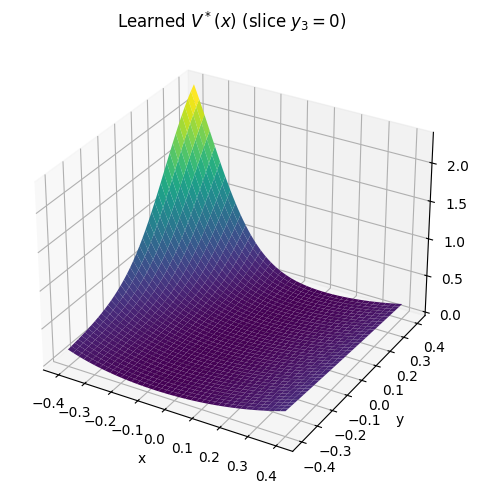

In [9]:
g2 = np.linspace(-L, L, 81)
GX, GY = np.meshgrid(g2, g2)
Yslice = np.stack([GX.ravel(), GY.ravel(), np.zeros(GX.size)], axis=1)
Vs = V_star(Yslice).reshape(GX.shape)
Vds = Vdot_star(Yslice).reshape(GX.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vs, cmap='viridis')
ax.set_title(r'Learned $V^*(x)$ (slice $y_3=0$)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/06_V_learned_cstr3d.png', dpi=150, bbox_inches='tight')
plt.show()

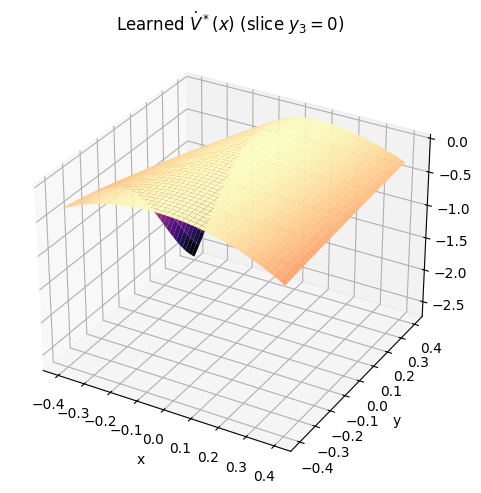

In [10]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vds, cmap='magma')
ax.set_title(r'Learned $\dot V^*(x)$ (slice $y_3=0$)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/06_Vdot_learned_cstr3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| | Result |
|---|---|
| System | Jacketed non-isothermal CSTR (3D: conversion, reactor temp, jacket temp) |
| Nonlinearity | Exponential ($e^{x_2}$), from Arrhenius rate law |
| Equilibrium | Low-conversion (cold) steady state, located numerically among 3 candidates; shifted to origin |
| Jacobian eigenvalues | $-0.5348,\ -1.0414,\ -1.2047$ (real, negative, distinct, non-resonant) |
| Other steady states | One unstable real-eigenvalue equilibrium and one with complex eigenvalues — both excluded |
| Method | Kernel/Koopman-eigenfunction PDE collocation, $d=3$, general left eigenvectors (non-diagonal $E$) |
| Gram matrices | All three positive definite |
| $V^*(0)$ | $\approx 0$ |
| $V^*(y)$, $y\neq0$ | $>0$ on all 5000 Monte Carlo samples checked |
| $\dot V^*(y)$, $y\neq0$ | $<0$ on all 5000 Monte Carlo samples checked |

This is a genuinely 3D real-world system (a chemical reactor with cooling-jacket dynamics) with
exponential nonlinearity, certified locally asymptotically stable using the same generalized
kernel/Koopman-eigenfunction method used throughout this notebook series.